In [31]:
import importlib
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
# add Modeling/ to Python path
project_root = Path.cwd().parents[2]
sys.path.append(str(project_root))
from Modeling.models.beam_properties import PiezoBeamParams
from Modeling.models.plotting import animate_field_1d
import matplotlib.pyplot as plt
from Modeling.models.ROM import ROM

import Modeling.models.FE3 as FE_module
import Modeling.models.FE_helpers as FE_helpers 
 
importlib.reload(FE_module)
import Modeling.models.envelope_soliton as envelope_soliton
importlib.reload(envelope_soliton)
HomogenizedModel = envelope_soliton.HomogenizedModel
import numpy as np
from numpy import pi	
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from IPython.display import clear_output
from matplotlib import cm, colors
import pandas as pd
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import pickle

In [32]:
%matplotlib widget
Q = 300
# params_fe = PiezoBeamParams( 
#     hp=0.55e-3, hs=0.51e-3, b=21e-3, w_p=21e-3, w_s=1e-3,
#     Q = Q
#     )
# params_fe.zeta_p = 0.0151
# params_fe.zeta_q = 0.0392
j_exc = 299
params_fe = PiezoBeamParams(
                            hp=0.252e-3, hs=0.51e-3
                            # hp=0.31e-3, hs=0.607e-3
                            , d31= -1.48e-10,eps_r=1700,
                            n_patches=Q
                            )
# # params_fe.zeta_p = 0.0151*8
# # params_fe.zeta_q = 0.0392*10
# j_exc = 30
params_fe.zeta_p = 0.0151
params_fe.zeta_q = 0.0392
fe = FE_module.PiezoBeamFE(params_fe,
                     n_el_patch=1,n_el_gap=1
                     )
x_eval = np.linspace(0, params_fe.L_b, 500)
R_c = 1e3; K_c = 1e10
K_i = 1000; K_p = 1e-4
f0 = 100; f1 = 3000

dt = 1/f1/20

ode = fe.build_ode_system(
    j_exc=j_exc,
    K_c=K_c,    # linear circuit
    K_i=K_i,
    K_p= K_p,
	v_exc=None
)

In [33]:
results_dir = Path('./results')
data_baese_name = 'soliton_FE_hardening_highdamping_longbeam_epsphi002'
data_baese_name = 'soliton_FE_hardening_highdamping_epsphi0.5'
with open(results_dir / f'{data_baese_name}.pkl', 'rb') as f:
    result = pickle.load(f)
    t = result['t']
    w = result['u']                # mechanical displacement
    w_dot = result['u_dot']        # mechanical velocity
    w_ddot = result['u_ddot']      # mechanical acceleration``
    q = result['q']                # electrical charge
    v = result['v']                # voltage

    spec_td = result['spectral']   # time-domain FRF dictionary (freq, FRF)
    for k in result.keys():
        if isinstance(result[k], np.ndarray):
            print(k, result[k].shape, result[k].dtype)
        if isinstance(result[k], dict):
            print(k, {kk: (  type(result[k][kk])) for kk in result[k].keys()})

envelope_params = result['envelope_params']
# ncycls = envelope_params['ncycls']
# delay_factor = envelope_params['delay_factor']
eps_phi = envelope_params['eps_phi']
# excitation_scale = envelope_params['excitation_scale']
K_c = result['K_c']
K_i = result['K_i']
K_p = result['K_p']
# R_c = result['R_c']

t (20000,) float64
u (20000, 601) float64
u_dot (20000, 601) float64
u_ddot (20000, 601) float64
q (20000, 299) float64
v (20000, 299) float64
x (20000, 1501) float64
x_dot (20000, 1501) float64
x_ddot (20000, 1501) float64
spectral {'freq': <class 'numpy.ndarray'>, 'FRF': <class 'numpy.ndarray'>, 'Y': <class 'numpy.ndarray'>, 'X': <class 'numpy.ndarray'>}
envelope_params {'omega0': <class 'int'>, 'vg0': <class 'numpy.float64'>, 'P0': <class 'numpy.float64'>, 'Q0': <class 'numpy.complex128'>, 'q0': <class 'float'>, 'eps_phi': <class 'float'>}


In [34]:
envelope_params
K_c, K_i, K_p

(300000.0, 220, 0.0001)

L=  4.545454545454546
Lc=  0.0033333333333333335
Peak omega0: 1845
Q: (-1.2314995996389522+0j)
P: 0.8489673739380169
Q/P: (21768.776282780695-0j)
eps_phi: 0.005000000000000001
sqrt Q0/(2P0)=  0.8516411533148851j


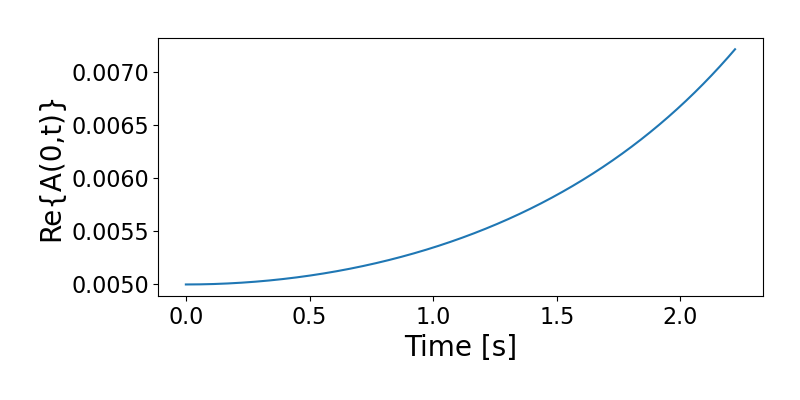

sqrt Q0/(2P0)=  0.8516411533148851j


In [50]:
R_c = 1e3; K_c = 3e5; K_i = 220; K_p = 1e-5
print('L= ', R_c / K_i)
print('Lc= ', R_c / K_c)
ref_scales = params_fe.nondimensional_scales(K_i=K_i, K_c=K_c, R_c=R_c)
hom_params = params_fe.homogenized_parameters(K_c=K_c, R_c=R_c, K_i=K_i)
# Build homogenized envelope using envelope_soliton module
hom_model = HomogenizedModel(
    ref_scales=ref_scales,
    hom_params=hom_params,
    branch= "acoustic"
)

peak = hom_model.peak_focus()

print("Peak omega0:", envelope_params['omega0'])
print("Q:", envelope_params['Q0'])
print("P:", envelope_params['P0'])
print("Q/P:", peak['Q_over_P'])

omega0 = envelope_params['omega0']  # set as in your sweep
eps_phi = envelope_params['eps_phi']
print("eps_phi:", eps_phi)
# ncycls = 100
# delay_factor = 0.3
envelope_func, envelope_params = hom_model.envelope(
    omega0=omega0,
    eps_phi=eps_phi
    )

envelope_func, envelope_params = hom_model.sec_envelope(
    omega0=omega0,
    eps_phi=eps_phi
    )

# Time signal at x=0
ncycls = 10000
t_eval = np.linspace(0, ncycls * ref_scales["t0"], ncycls * 1000)
A_t = envelope_func(0.0, t_eval)

plt.figure(figsize=(8, 4))
plt.plot(t_eval, np.real(A_t))
plt.xlabel("Time [s]")
plt.ylabel("Re{A(0,t)}")
plt.tight_layout()
plt.show()

# Optional: excitation voltage (same as make_v_exc)
v_exc = hom_model.make_v_exc(omega0, eps_phi, t_eval, t_shift=t_eval[-1]*0.765)

In [36]:
t[-1]

np.float64(0.13179409308821416)

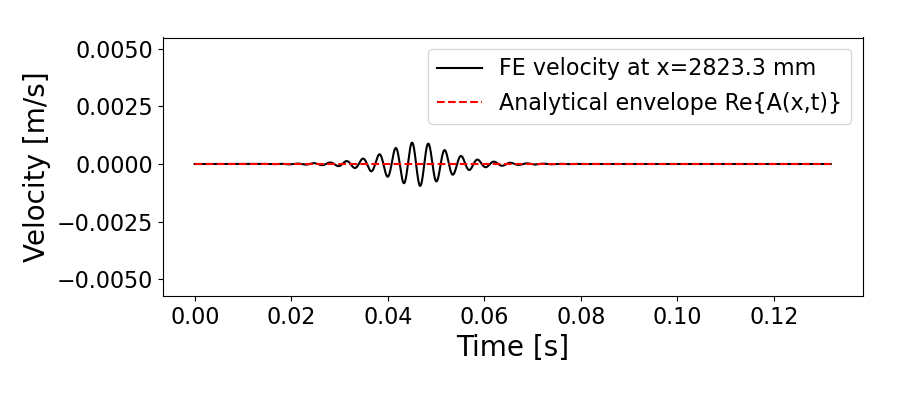

In [51]:
# ...existing code...

# Plot FE response vs analytical envelope at spatial node
# idx = w_dot.shape[1] // 2  # mid-span node
idx =  550
x_node = fe.geom.x_nodes[idx + 1]  # spatial position of this node (+1 for fixed BC)
t_fe = t
field = w_dot
anal_scale = 6e-5

# Envelope evaluated at the spatial position of the FE node
A_t = envelope_func(-(x_node - fe.geom.x_nodes[-1])#+4.55
                    , t_fe-delay_factor*t_eval[-1])  # adjust time shift as needed

plt.figure(figsize=(9, 4))
plt.plot(t_fe, field[:, idx], 'k-', lw=1.5, label=f'FE velocity at x={x_node*1e3:.1f} mm')
plt.plot(t_fe, np.real(A_t)*anal_scale, 'r--', lw=1.5, label='Analytical envelope Re{A(x,t)}')
plt.xlabel('Time [s]')
plt.ylabel('Velocity [m/s]')
plt.legend()
plt.ylim([field.min()*1.2, field.max()*1.2])
plt.tight_layout()
plt.show()

# ...existing code...

# ...existing code...

Saving frame 150/150Saved animation to ./results/anim/soliton_FE_hardening_highdamping_epsphi0.5.mp4


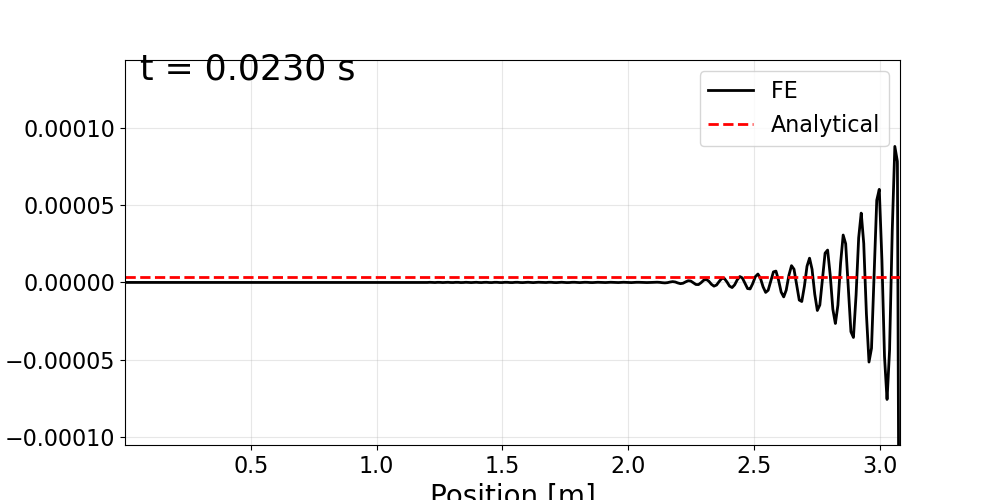

In [52]:
# After creating envelope_func and loading FE results
from Modeling.models import plotting
importlib.reload(plotting)
delay_factor = 0.1475
speed_correction = 0.9
scale_correction = 7e-4
t_eval = t
A_t = lambda x, t: envelope_func(-(x - fe.geom.x_nodes[-1])#+4.55
                    , (t-delay_factor*t_eval[-1])*speed_correction)*scale_correction  # adju
temporal_slice = slice(0, 1000)
temporal_slice = slice(2000, 3500)
plotting.animate_field_1d_with_envelope(
    t=t[temporal_slice],
    u=w_dot[temporal_slice],  # or w for displacement
    envelope_func=A_t,
    x=fe.geom.x_nodes[1:],  # spatial grid
    filename=f"./results/anim/{data_baese_name}.mp4",
    scale=1.0,
    stride=10,
    ylabel="Velocity [m/s]",
    xlabel="Position [m]",
    fps=50
    # scale=1
    # y_lim_scale=0.8
)

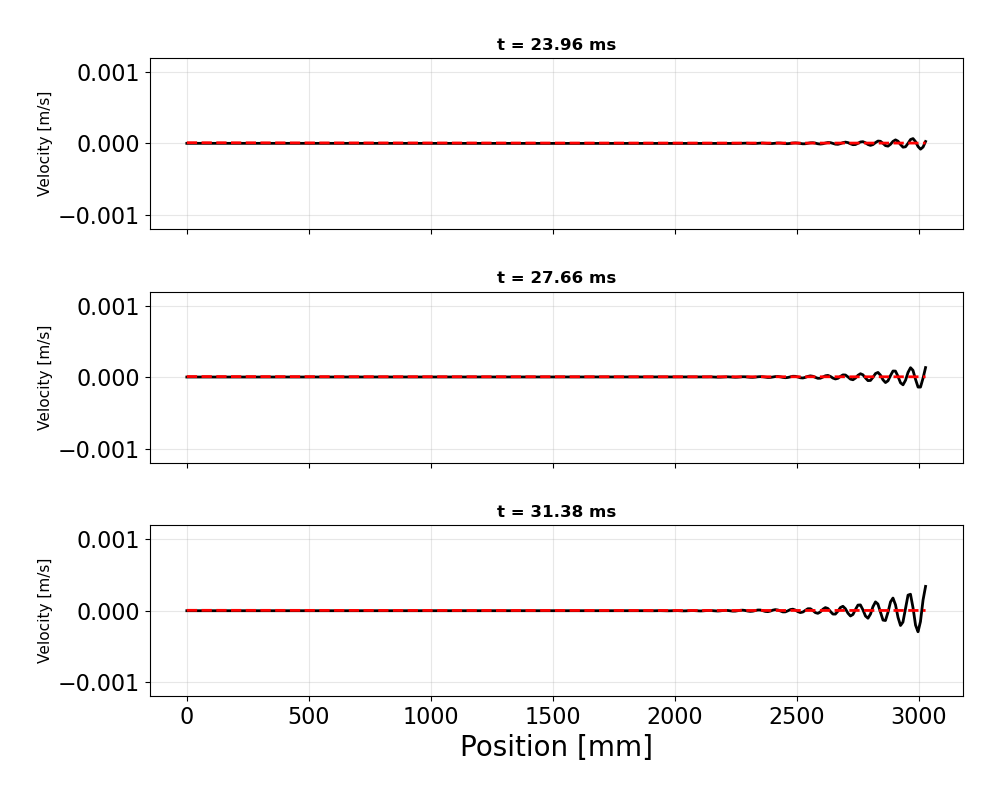

In [39]:
"""
Plot wave field at three time instances to show wave propagation
"""
plt.rcParams.update({
"font.size": 25,
"axes.labelsize": 20,
"xtick.labelsize": 16,
"ytick.labelsize": 16,
"legend.fontsize": 8*2,
# "axes.labelsize": 50,
})
# Select three time instances
n_times = 3
time_indices = np.linspace(len(t)//5.5, len(t)//4.2, n_times, dtype=int)

# Spatial grid (exclude fixed BC node)
x_spatial = fe.geom.x_nodes[1:-10]

fig, axes = plt.subplots(n_times, 1, figsize=(10, 8), sharex=True)

for i, (ax, t_idx) in enumerate(zip(axes, time_indices)):
    # FE wave field at this time
    fe_field = w_dot[t_idx, :-10]
    
    # Analytical envelope at this time
    A_spatial = np.array([envelope_func(-(x - fe.geom.x_nodes[-1]), 
                                        (t[t_idx] - delay_factor*t_eval[-1])*speed_correction)*scale_correction
                         for x in x_spatial])
    
    # Plot
    ax.plot(x_spatial * 1e3, fe_field, 'k-', lw=2, label='FE')
    ax.plot(x_spatial * 1e3, np.abs(A_spatial) , 'r--', 
            lw=2, label='Analytical envelope')
    
    ax.set_ylabel('Velocity [m/s]', fontsize=11)
    ax.set_title(f't = {t[t_idx]*1e3:.2f} ms', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    # ax.legend(loc='upper right')
    
    # Set consistent y-limits
    y_max = np.abs(field).max() * 0.25
    ax.set_ylim([-y_max, y_max])

axes[-1].set_xlabel('Position [mm]')
plt.tight_layout()
plt.show()